In [146]:
from dotenv import load_dotenv
load_dotenv()

True

In [147]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_groq import ChatGroq
from typing import Literal
from pydantic import BaseModel, Field

##for google agent
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent
from langchain.tools import tool

### State

In [148]:
class chatstate(BaseModel):
    questions:str = Field(description="user asked questions")
    category: Literal['google_search', 'weather', 'coding'] = Field(default='google_search')
    answer:str = Field(default="")
    


In [149]:
class categorystate(BaseModel):
    category: Literal['google_search', 'weather', 'coding'] = Field(default='google_search',
                                                                    description="Question Category")

### node,edges

In [150]:
llm = ChatGroq(model = "openai/gpt-oss-120b")

In [151]:
#Google Agent

ggl_search = GoogleSerperAPIWrapper(serper_api_key="0c9fb20f81243147ab43b8db173fad790b0a80b9")
google_agent = create_agent(
    model=llm,
    tools=[ggl_search.run],
    system_prompt="Google search agent."
)

#Weather Agent

@tool
def get_weather(city:str):
    """this is a weather agent tool."""
    return f"the current temp of {city} is x degree."


weather_agent = create_agent(
    model=llm,
    tools=[get_weather],
    system_prompt="Weather agent."
)


In [152]:
r = weather_agent.invoke({"message":[{"role":"user","content":"what is temp of bangalore?"}]})

r["messages"][-1].content

'Sure thing! Which city (or location) would you like the current weather for?'

In [153]:
def chatquestioncat(state:chatstate)->chatstate:
    st_llm = llm.with_structured_output(categorystate)
    res = st_llm.invoke(f"I want to know category of my question:{state.questions}")
    state.category = res.category
    return state

In [154]:
## 2nd Node - Route

def route(state:chatstate) -> Literal['google_search', 'weather', 'coding']:
    return state.category


In [155]:
# After Routing : 3 Nodes

def coding_node(state:chatstate)->chatstate:
    print("coding node")
    res = llm.invoke(f"You are a coding expert:{state.questions}")
    state.answer = res.content
    return state

def weather_node(state:chatstate)->chatstate:
    res = weather_agent.invoke({"messages":[{"role":"user","content":state.questions}]})
    state.answer =  res["messages"][-1].content
    return state

def google_search_node(state:chatstate)->chatstate:
    res = google_agent.invoke({"messages":[{"role":"user","content":state.questions}]})
    state.answer =  res["messages"][-1].content
    return state

In [156]:
graph1 = StateGraph(chatstate)

graph1.add_node("chatquestioncat",chatquestioncat)
# graph.add_node("route",route) -- because its a conditional node.so it will not work like real node.
graph1.add_node("coding",coding_node)
graph1.add_node("weather",weather_node)
graph1.add_node("google_search",google_search_node)


In [157]:
graph1.add_edge(START,"chatquestioncat")
graph1.add_conditional_edges("chatquestioncat",route)
graph1.add_edge("coding",END)
graph1.add_edge("weather",END)
graph1.add_edge("google_search",END)

graph1 = graph1.compile()

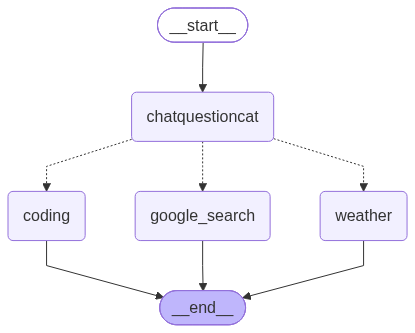

In [158]:
from IPython.display import Image
Image(graph1.get_graph().draw_mermaid_png())

In [159]:
res = graph1.invoke({"questions":"what is temperature in bangalore now?"})

res

{'questions': 'what is temperature in bangalore now?',
 'category': 'weather',
 'answer': 'The current temperature in Bangalore is **x\u202f°C**.'}